# Task 3 – Manual tuning and evaluation on all tests
The manually tuned DFN parameter set is simulated for all six tests (Charge 1C–4C, Discharge 1C, HPPC) and compared with the measurements.

###  Residual analysis

The baseline Prada2013 model and the manually tuned model are run on the HPPC profile. The residual (model minus measurement) is plotted over time and against SOC, and the table splits the RMSE into rest vs. pulses and into SOC ranges.

What the residuals show:
- **First minute:** a small offset because the cell is not fully relaxed at the start of the test. This is a measurement effect, not a model error.
- **Near full charge:** the baseline voltage is off because the LFP OCP wall is too steep and the stoichiometry at full charge is not right.
- **Rest periods:** a steady offset means the OCV (OCP curves plus stoichiometry window) doesn't match the cell.
- **During pulses:** the instant drop and the relaxation afterwards come from resistance, reaction kinetics and diffusion.
- **Low SOC:** with the baseline, the voltage collapses and the simulation stops early. The graphite surface runs out of lithium because Prada's graphite diffusivity is too low for this cell, and the capacity window is also off.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_DIR = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn")
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import pandas as pd
from lfp_dfn import CellConfig, ProtocolConfig, CellModel, run_all

### 1. Setup
Loads the project package (`lfp_dfn`) with the cell model, data loading, simulation and plotting functions. Autoreload picks up changes in the `.py` files without restarting the kernel.

In [2]:
DATA_DIR = Path(r"K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\Data_dir")
OUT_DIR  = PROJECT_DIR / "results" / "all_tests"
TESTS    = ["Charge_1C", "Charge_2C", "Charge_3C", "Charge_4C", "Discharge_1C", "HPPC"]

protocol = ProtocolConfig(v_cv=3.6)

cfg = CellConfig(
    x100=0.9082,
    graphite_ocp="Chen2020",
    use_soft_wall=True,
    k_wall=70,
    v_full_rest=3.447,
    du_charge=0.0,
    D_n=1.5e-14,
    D_p=5.8e-18,
    beta_p=0.2,
    delta_p=0.15,
    eps_n=0.58,
    eps_p=0.374,
    k_j0_n=1.0,
    k_j0_p=1.0,
    R_contact=0.0,
    T_default_C=23.0,
)

cell = CellModel(cfg)
print(cell.summary())

Graphite OCP: Chen2020 | soft wall: True (k=70) | y100 = 0.0191 | dU_charge = 0 mV | Q_n = 2.907 Ah, Q_p = 3.292 Ah | R_contact = 0.00 mOhm


### 2. Configuration
Defines the data and output folders, the test list, the charging protocol (CV at 3.6 V) and the manually tuned cell parameters (stoichiometry window, OCP wall, diffusivities, kinetics), then builds the cell model.

Running Charge_1C ...


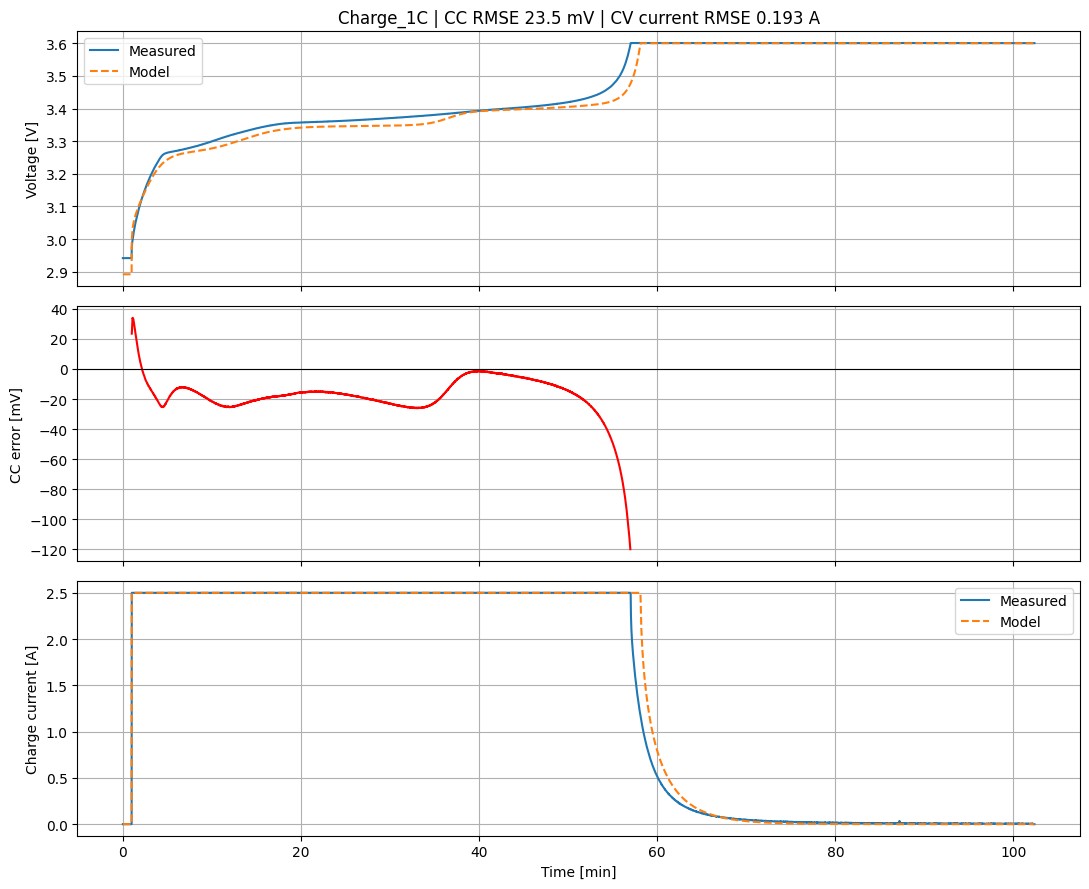

  done in 2 s
Running Charge_2C ...


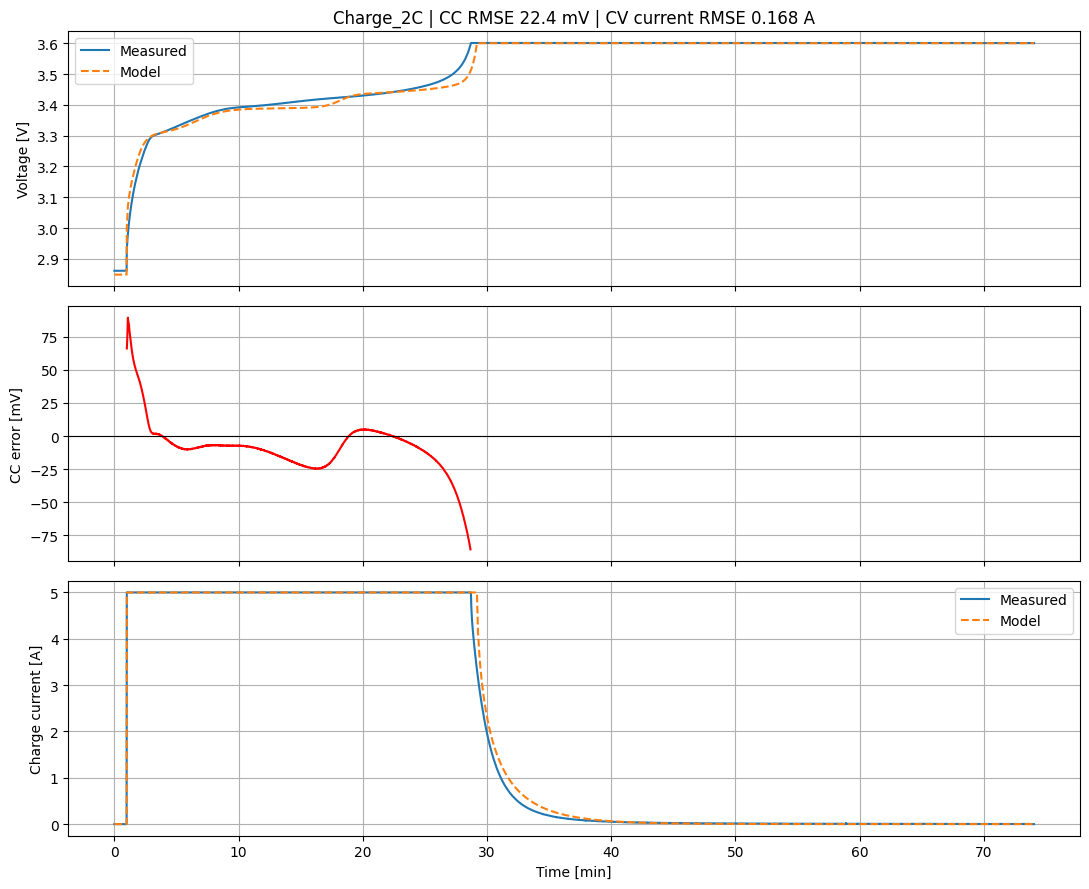

  done in 2 s
Running Charge_3C ...


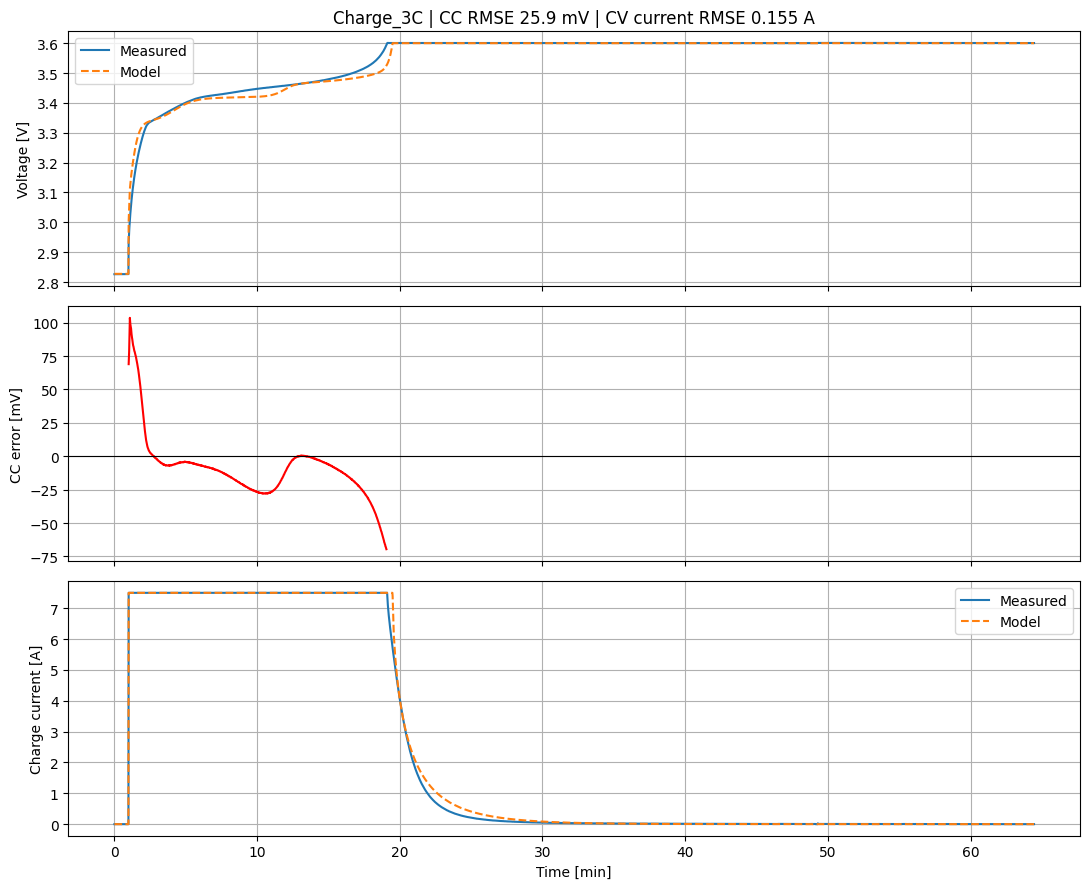

  done in 2 s
Running Charge_4C ...


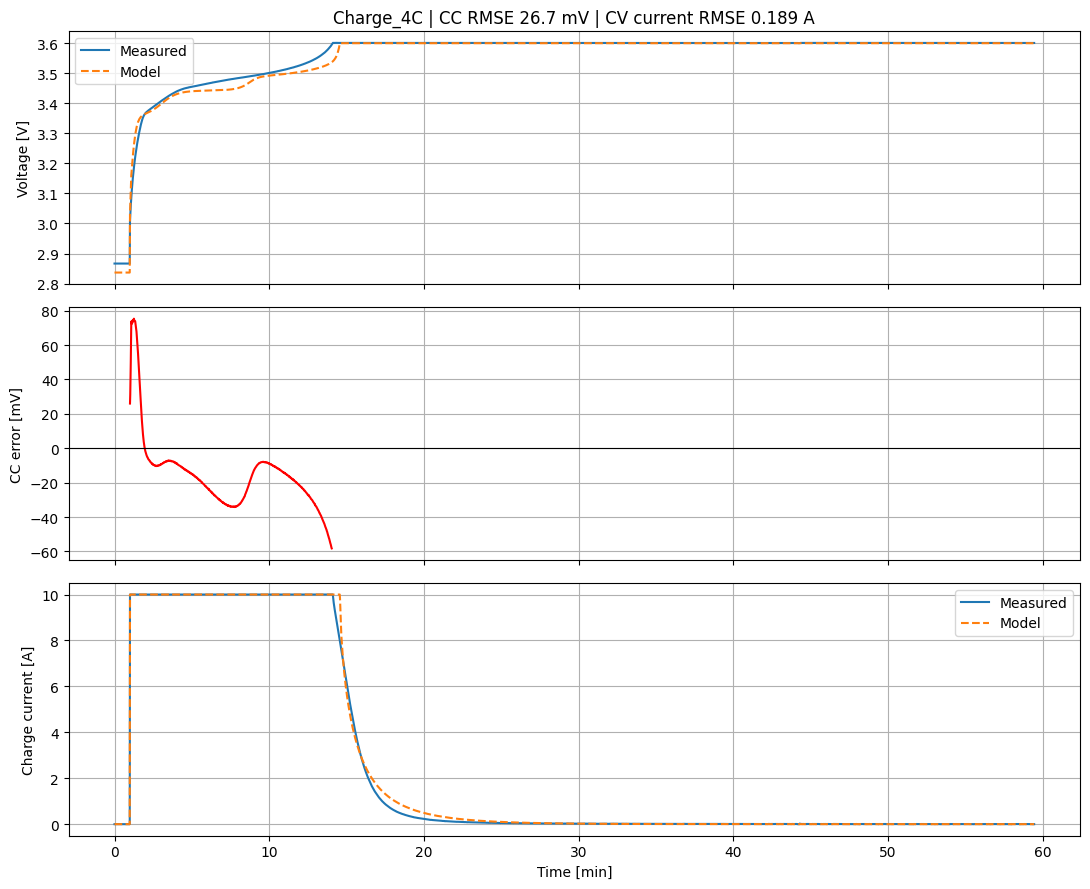

  done in 2 s
Running Discharge_1C ...


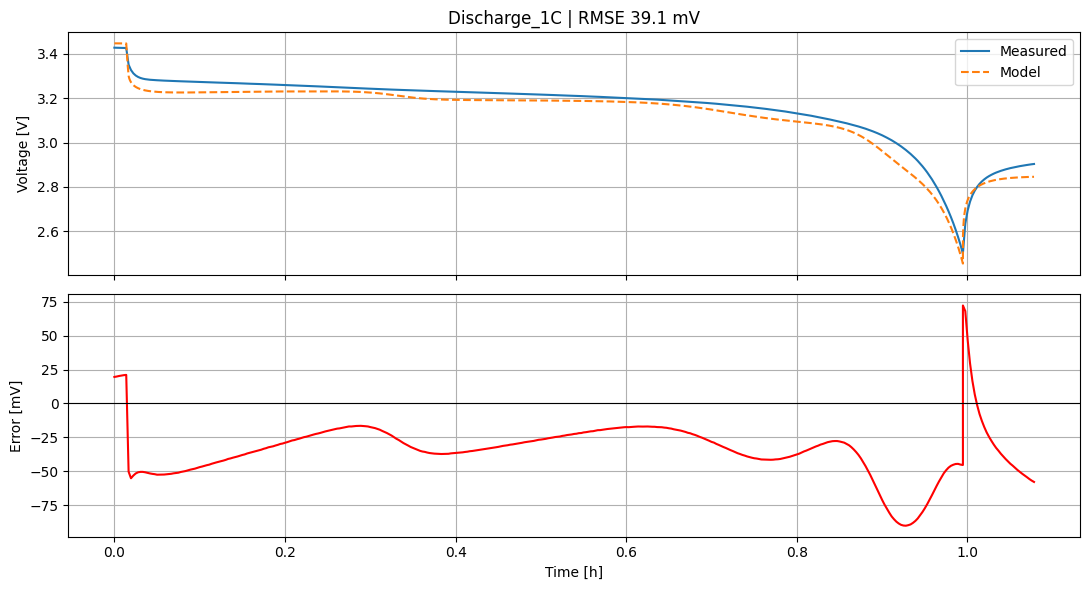

  done in 2 s
Running HPPC ...


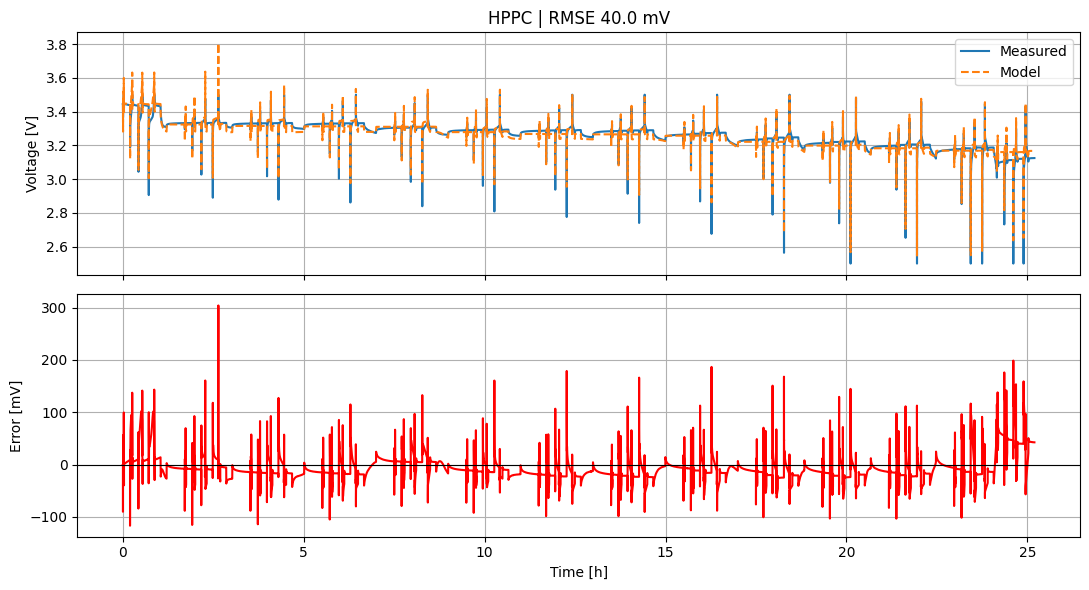

  done in 115 s

Saved to K:\chalmers\DML\deep-machine-learning\Pybamm_DFN\lfp_dfn\results\all_tests: all_<test>.png, summary CSVs, run_config.json


In [3]:
charge_tbl, current_tbl = run_all(cell, TESTS, DATA_DIR, protocol, OUT_DIR, show_plots=True)

### 4. Results
Charge tests: CC voltage RMSE, CV current RMSE, CV start time and charge accepted. Discharge and HPPC: RMSE, MAE, max error, and RMSE during rest vs. current-on periods.

In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

print("=== Charge tests (CC-CV, voltage-controlled CV) ===")
display(charge_tbl.round(3))

print("=== Discharge and HPPC (current-driven) ===")
display(current_tbl.round(3))

=== Charge tests (CC-CV, voltage-controlled CV) ===


,RMSE V CC [mV],Mean offset CC [mV],RMSE I CV [A],CV start model [min],CV start meas [min],Charge model [Ah],Charge meas [Ah]
Test,,,,,,,
Charge_1C,23.464,-18.027,0.193,58.097,56.996,2.460,2.423
Charge_2C,22.403,-8.311,0.168,29.171,28.684,2.484,2.447
Charge_3C,25.867,-9.039,0.155,19.483,19.080,2.494,2.456
Charge_4C,26.727,-15.267,0.189,14.557,14.055,2.490,2.452


=== Discharge and HPPC (current-driven) ===


,Simulated [h],Test length [h],Stop reason,RMSE V [mV],MAE V [mV],Max |error| [mV],RMSE rest [mV],RMSE current on [mV]
Test,,,,,,,,
Discharge_1C,1.078,1.078,final time,39.142,35.527,89.990,39.810,39.069
HPPC,25.195,25.195,final time,40.032,30.216,303.925,31.556,58.609


,Coverage [%],RMSE all [mV],Mean error [mV],RMSE rest [mV],RMSE discharge pulses [mV],RMSE charge pulses [mV],RMSE high SOC 100-70 % [mV],RMSE mid SOC 70-30 % [mV],RMSE low SOC 30-0 % [mV]
Prada2013 baseline,64.6,63.2,-8.2,56.5,85.8,72.3,72.3,39.3,100.8
Manual tuning,100.0,40.0,2.9,31.6,65.1,51.2,39.0,35.0,43.8


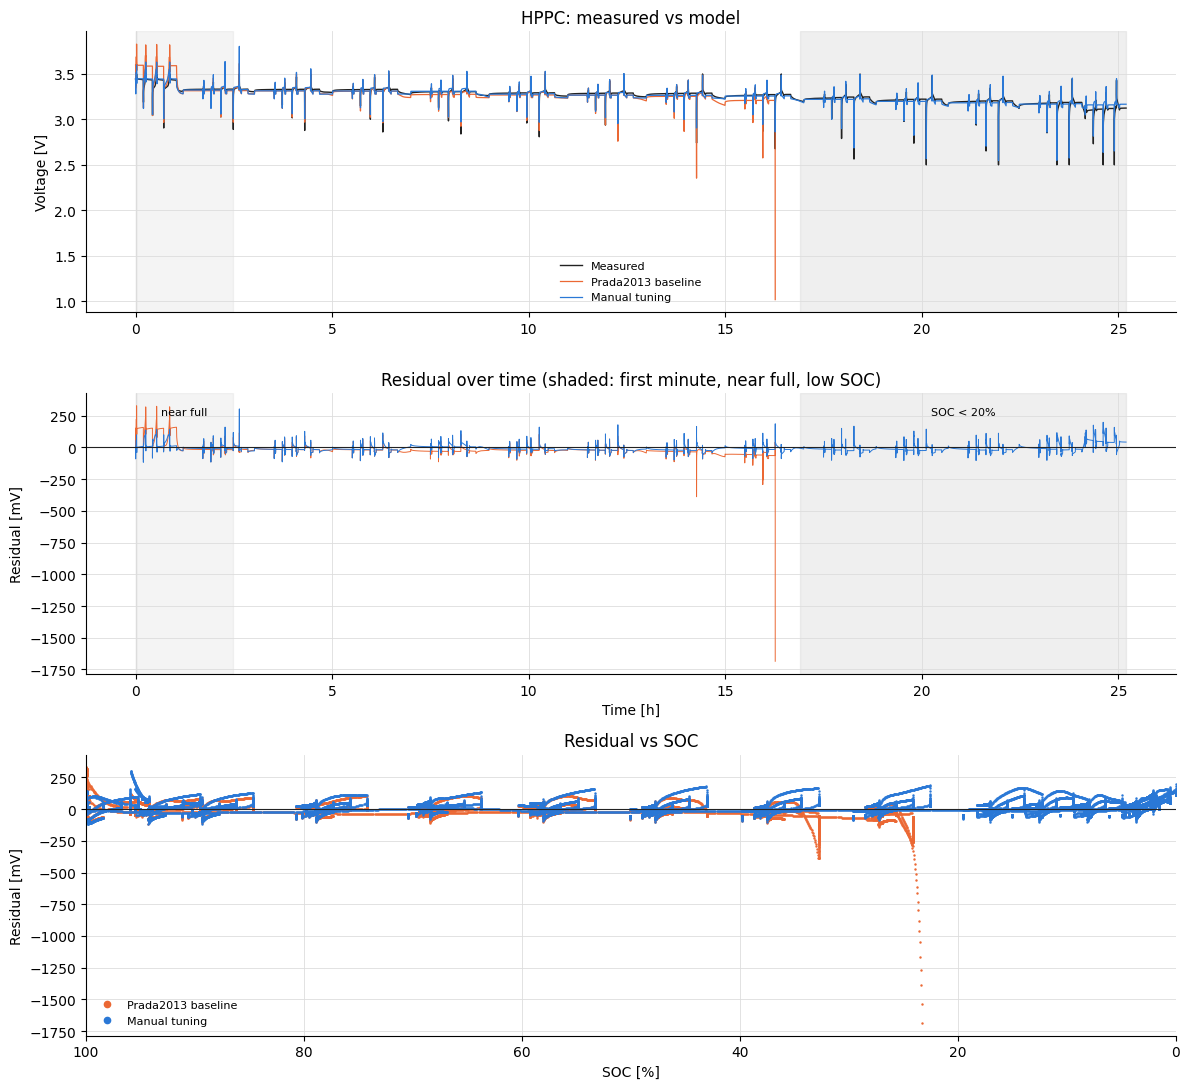

In [5]:
from lfp_dfn import CellConfig, CellModel, load_test
from lfp_dfn.residuals import hppc_residuals, residual_table, plot_residuals

# Original Prada2013 values (no tuning) as the reference
baseline_cfg = CellConfig(x100=0.81, y100=0.0038, use_soft_wall=False,
                          D_n=3e-15, D_p=5.9e-18, beta_p=1.0, k_j0_n=1.0, k_j0_p=1.0)

hppc = load_test(DATA_DIR, "HPPC", cfg.T_default_C)
residuals = {
    "Prada2013 baseline": hppc_residuals(CellModel(baseline_cfg), hppc),
    "Manual tuning":      hppc_residuals(cell, hppc),
}

res_tbl = residual_table(residuals, protocol)
display(res_tbl.round(1))
res_tbl.to_csv(OUT_DIR / "hppc_residual_table.csv")
plot_residuals(hppc, residuals, OUT_DIR / "hppc_residuals.png")

###  Which parameters to tune

The parameters are split into two groups by what they affect.

| Group | Parameters | Affects | How it is handled |
|---|---|---|---|
| Thermodynamic (static) | x100, y100, ε_n, ε_p, OCP curves, LFP wall (k_wall) | capacity and rest voltage | manual tuning against capacity and HPPC rest voltages (Task 3) |
| Dynamic | D_n, D_p, β_p, k_j0_n, k_j0_p, R_contact | voltage under load, CV current | optimization on the charge/discharge tests (Task 4) |

The static group is fixed first, so that the optimizer can't hide kinetic errors by bending the OCV. Geometry and material constants stay at the Prada2013 values, because the terminal voltage alone can't tell them apart from the parameters above.

###  External sources and assumptions

- **Prada2013 (base parameter set):** made for an A123 26650 LFP/graphite cell with 2.3 Ah nominal capacity. Our ANR26650M1B is the 2.5 Ah version. We assume the same chemistry and geometry and correct the capacity through the stoichiometry window.
- **Chen2020 graphite OCP:** measured on an LG M50 cell. Graphite OCP depends mainly on the material, so the curve shape is assumed to carry over, with the alignment set by x100.
- **Afshar2017 LFP OCP:** a general LFP curve. The flat plateau is typical of LFP; only the wall steepness near full charge was adjusted to our data.
- **Forman et al. (2012):** used as a reference for the optimization approach (GA-based DFN identification on an A123 LFP cell), not as a source of parameter values.